# Training probes on hidden states projected onto vocab space
- Generate qa_accuracy and obtain hidden states(residual stream) for given layers.
- Later, we individually project each layer's hidden state onto vocab space.
- Generate MinMax scaler features by fitting on training set.
- Use the MinMax scalers to normalize the representation.
- Get the average of the representation over the 3 layers and save the dataset to huggingface.
- Consequently train probe on `top-k` values used in paper with selected and optimal hyperparameters generated from training on residual stream.

## Experiments on top-k logits
For hyperparameters selected during hidden states
- top-200 logits, run_1,  `lr = 0.00001, wd=0.01, batch_size=32 and epoch = 500` corr = -0.02
- top-200 logits, run_2, `lr = 0.00001, wd=0.01, batch_size=32 and epoch = 100` corr = 0.04
- top-200 logits, run_3, `lr = 0.00001, wd=0.01, batch_size=32 and epoch = 1000` corr = -0.02
- top-200 logits, run_4, `lr = 0.00001, wd=0.01, batch_size=32 and epoch = 3000` corr = -0.01

## VP-k feature
- Extract logits in vocab space per layer per subject.
- Normalize using MinMax scaler.
- Average normalized logits across layer for each subject.
- Train probe with the averaged logits.
- Extract `top-k` token ids on the learned weights of the probe.
- Use the extracted `top-k` token ids to extract logits per layer per subject.
- Normalize and average and use it to train the probe.
- Hopefully, this generates good result.

### How to get VP-k features
Now that I have logits for 3 late layers in gpt2-xl and the indices that of most weighted tokens based on training probe on full logits. What is the way forward?

## NOTES
- Firstly, I experimented with `top-k ranked tokens per subject`. This produced terrible results with test correlation in the negative even with optimal hyperparameters. This suggests this is not the approach to follow because `top-k ranked tokens per subject` does not produce stable tokens as features for training. This means there can be different token ids represented in each ranked position/feature by each subject. This does not make the feature interpretable. So maybe I need to read up the paper more to really understand how to build the `VP-k` feature the KEEN probe was trained on.
- According to ChatGPT, it seems KEEN probe is to be trained on full logits in vocab space on the given layers, optionally normalize and then averaged across layers. This averaged logits across the layers is then used to train a probe. `VP-k` features are then extracted from the `top-k` token ids is then extracted from weights of the trained probe, this is then used to train the probe.

## TRAINING
- Train probe with full vocab size with best hyperparameter `lr = 0.00001, wd=0.01, batch_size=32 and epoch = 500`.
- Save weights and grab top-k indices of the weights.
- Perhaps save these indices as artifacts on HF so they can be loaded on demand for extracting their respective logits per layer in the dataset for training.

## Findings
>I did 2 runs for seed 1234 since no need results seem random
- Full logits, run_1,  `lr = 0.00001, wd=0.01, batch_size=32 and epoch = 500` corr = 0.64(T4 GPU),  (A40 GPU)
- VP-200 feature, run_1,  `lr = 0.00001, wd=0.01, batch_size=32 and epoch = 500` corr = 0.50(NS), 0.49, 0.51, 0.49, 0.49, 0.49 (Now not in T4 but in A40 GPU)
- VP-100 feature, run_1,  `lr = 0.00001, wd=0.01, batch_size=32 and epoch = 500` corr = 0.21(NS), 0.33, 0.39, 0.33, 0.33, 0.33 (Now not in T4 but in A40 GPU)
- VP-50 feature, run_1,  `lr = 0.00001, wd=0.01, batch_size=32 and epoch = 500` corr = 0.32(NS), 0.21, 0.31, 0.17, 0.17, 0.17 (Now not in T4 but in A40 GPU)
- VP-25 feature, run_1,  `lr = 0.00001, wd=0.01, batch_size=32 and epoch = 500` corr = 0.02(NS), 0.11, -0.03, 0.22, 0.22, 0.22 (Now not in T4 but in A40 GPU)
- VP-10 feature, run_1,  `lr = 0.00001, wd=0.01, batch_size=32 and epoch = 500` corr = 0.23(NS),  0.18, 0.16, 0.06, 0.06, 0.06(Now not in T4 but in A40 GPU)

>NOTE: The last 3 runs for VP-k features were stable on deterministic seed on A40 GPU. My informed guess is that the previous runs were erratic because I did not restart the kernel after each run. I think this is one of the benefits of doing this kind of multiple runs in a script.

- k = [50257, 200, 100, 50, 25, 10], corr = [0.63, 0.49, 0.33, 0.17, 0.22, 0.06]

# Short notes on EleutherAI

Happy New Year

Yeah, I got around starting to reproduce a bit of the result in the KEEN paper like I previously said. This is what I have done so far:

- Generated a keen-style PopQA subjects data using gpt2_xl
- Generated QA accuracy and residual stream(hidden states) data relating to the subjects.
- Trained a probe on the residual stream data to obtain a test correlation of 0.64(in aggrement with the paper result).
- Created logits using residual stream data and then generate VP-k features based on top absolute number of the learned weights of the probe.
- Trained probe with different number of k features such as `50257, 200, 100, 50, 25, 10` where 50257 is the vocab size of the gpt2-xl model. I got a test correlation values of `0.63, 0.49, 0.33, 0.17, 0.22, 0.06`. The line graph below shows the general trend of the paper result except that there appears to be a dropoff of the correlation value at k=50 before going back to the uptrend. This small divergence to the KEEN paper could be a result of the fact I used an epoch of __500__ instead of __100__ as I got best my result with residual stream data with epoch 500
- The following hyperparameters were used: `lr=0.00001, batch_size=500, epoch=500, wd=0.01`


In [4]:
# @title Install dependencies
# !pip install -q \
#   torch \
#   transformers \
#   datasets \
#   accelerate \
#   numpy \
#   pandas \
#   scikit-learn \
#   scipy \
#   joblib \
#   tqdm \
#   wandb \
#   huggingface-hub \
#   matplotlib \
#   seaborn

In [ ]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # or ":16:8"

In [ ]:
# @title Set deterministic seed
import os
import random
import numpy as np
import torch


def set_deterministic_seed(seed: int = 42) -> None:
    """
    Set deterministic behavior for Python, NumPy, and PyTorch (CPU & CUDA).
    Note: This may reduce performance and disable some CUDA optimizations.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"


# Call this ONCE at the very start of your program / notebook
set_deterministic_seed(1234)

In [ ]:
# @title Imports
from __future__ import annotations

import os
from typing import Callable, Dict, List, Optional, Protocol, Sequence, Tuple

import joblib
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler
from huggingface_hub import hf_hub_download
from transformers import PreTrainedTokenizerBase

In [ ]:
# @title Get topk_indices
from huggingface_hub import hf_hub_download

top_k = 10 # @param {type:"integer"}

def get_topk_indices(top_k: int) -> list:
  scalers_path = hf_hub_download(
    repo_id="kokolamba/keen_popqa_gpt2xl_generations",
    filename="top_k_indices/gpt2_xl_top_k_indices.joblib",
    repo_type="dataset"
)
  artifact = joblib.load(scalers_path)
  top_k_indices = artifact[f"top_{top_k}_indices"]
  return top_k_indices

top_k_indices = get_topk_indices(top_k)

assert len(top_k_indices) == top_k, f"Expected {top_k} indices, got {len(top_k_indices)}"


In [ ]:
# @title Full Dataset and Dataloader

from datasets import load_dataset
import pandas as pd
import torch
from torch.utils.data import Dataset
from ast import literal_eval
from tqdm import tqdm
import numpy as np
tqdm.pandas()

class HiddenStatesDataset(Dataset):
    def __init__(self, X_train, y_train):
        self.df = X_train
        self.labels = y_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        hidden_states = self.df.iloc[idx]
        accuracy = self.labels.iloc[idx]
        return torch.tensor(hidden_states, dtype=torch.float32), torch.tensor(accuracy, dtype=torch.float32)

def load_train_split(filename: str) -> pd.DataFrame:
    path = hf_hub_download(
        repo_id="dhgottesman/keen_estimating_knowledge_in_llms",
        filename=filename,
        repo_type="dataset",
    )
    return pd.read_csv(path, index_col=0)

def split_dataset_into_train_val_test(dataset, features="logits", use_vp_k=False, top_k=200, top_k_indices=[]):
    train_subjects = load_train_split("popqa_train_subjects.csv")
    val_subjects = load_train_split("popqa_val_subjects.csv")
    test_subjects = load_train_split("popqa_test_subjects.csv")

    train_df = dataset.merge(train_subjects, on="subject").dropna()
    val_df = dataset.merge(val_subjects, on="subject").dropna()
    test_df = dataset.merge(test_subjects, on="subject").dropna()

    if use_vp_k:
      X_train = train_df["logits"].apply(lambda v: np.asarray(v, dtype=np.float32)[top_k_indices])
      X_val = val_df["logits"].apply(lambda v: np.asarray(v, dtype=np.float32)[top_k_indices])
      X_test = test_df["logits"].apply(lambda v: np.asarray(v, dtype=np.float32)[top_k_indices])
    else:
      X_train = train_df[features]
      X_val = val_df[features]
      X_test = test_df[features]
      print("Running full logits features")

    y_train = train_df["accuracy"]
    y_val = val_df["accuracy"]
    y_test = test_df["accuracy"]
    return X_train, y_train, X_val, y_val, X_test, y_test

In [ ]:
from huggingface_hub import hf_hub_download

repo_id = "kokolamba/keen_popqa_gpt2xl_generations"
path_in_repo = f"features/logits.parquet"

local_path = hf_hub_download(
    repo_id=repo_id,
    repo_type="dataset",
    filename=path_in_repo,
)

qa_dataset = pd.read_parquet(local_path)

In [ ]:
# Length of logits representation
print(len(qa_dataset["logits"][0]))
print(local_path)

50257
/root/.cache/huggingface/hub/datasets--kokolamba--keen_popqa_gpt2xl_generations/snapshots/6b3999f22c4310f3b25a43be8a9d553390bf409e/features/logits.parquet


In [ ]:
# @title Setup model and tokenizer
import torch
import transformers
import re

def set_requires_grad(requires_grad, *models):
  for model in models:
    if isinstance(model, torch.nn.Module):
      for param in model.parameters():
        param.requires_grad = requires_grad
    elif isinstance(model, (torch.nn.Parameter, torch.Tensor)):
      model.requires_grad = requires_grad
    else:
      assert False, "unknown type %r" % type(model)


class GPTModelAndTokenizer:
  """An object to hold a GPT-style language model and tokenizer."""

  def __init__(
      self,
      model_name=None,
      model=None,
      tokenizer=None,
      low_cpu_mem_usage=False,
      torch_dtype=None,
      ):
    if tokenizer is None:
      assert model_name is not None
      tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
    if model is None:
      assert model_name is not None
      model = transformers.AutoModelForCausalLM.from_pretrained(
          model_name, low_cpu_mem_usage=low_cpu_mem_usage,
          torch_dtype=torch_dtype
          )
      set_requires_grad(False, model)
    self.tokenizer = tokenizer
    self.model = model
    self.layer_names = [
        n
        for n, _ in model.named_modules()
        if (re.match(r"^(transformer|gpt_neox)\.(h|layers)\.\d+$", n))
    ]
    self.num_layers = len(self.layer_names)
    self.vocabulary_projection_function = lambda x, layer: self.model.lm_head(self.model.transformer.ln_f(x)) if layer < self.num_layers else self.model.lm_head(x)
    self.mlp_hidden_size = self.model.config.n_embd * 4
    print(self.mlp_hidden_size)
    print(self.model.config)

  def __repr__(self):
    """String representation of this class.
    """
    return (
        f"ModelAndTokenizer(model: {type(self.model).__name__} "
        f"[{self.num_layers} layers], "
        f"tokenizer: {type(self.tokenizer).__name__})"
        )


In [ ]:
# @title Setup prompt template

def document_prefix(subject):
    return f"This document describes {subject}"

In [ ]:
# @title Load gpt2-xl
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mt = GPTModelAndTokenizer(model_name="gpt2-xl") # Corrected model name
mt.tokenizer.pad_token = mt.tokenizer.eos_token # Set pad_token to eos_token
mt.model = mt.model.to(device)
mt.model.eval()

print("num_layers:\n", mt.num_layers)

6400
GPT2Config {
  "activation_function": "gelu_new",
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "dtype": "float32",
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 1600,
  "n_head": 25,
  "n_inner": null,
  "n_layer": 48,
  "n_positions": 1024,
  "output_past": true,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "transformers_version": "4.57.3",
  "use_cache": true,
  "vocab_size": 50257
}

num_layers:
 48


# Linear Probe

We define the probe as one linear layer: `f(z, θ) := θ · z`.

Where:

- `z` is the hidden representation vector for an entity
- `θ` is a learnable parameter vector (same size as `z`)

In training, we aim to increase the correlation between the score predicted by the probe and the gold **label** metric (QA accuracy).


## Train a probe on the Top-k values

In [ ]:
# @title Set Top-k value

# We first start with full vocab size
# Then 200, 100, 50, 25, 10
# top_k = 200 # @param {type:"integer"}

In [ ]:
# @title LinearProbe
import torch.nn as nn
import torch.optim as optim
import copy
from scipy.stats import pearsonr
import wandb
from tqdm import tqdm

class LinearProbe(nn.Module):
    def __init__(self, input_size, learning_rate, max_iter, weight_decay=0.01):
        super().__init__()
        self.max_iter = max_iter
        self.criterion = nn.MSELoss()
        self.layer = nn.Linear(input_size, 1, bias=False)
        self._initialize_weights()

        self.optimizer = optim.AdamW(self.parameters(), lr=learning_rate, weight_decay=weight_decay)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=self.max_iter)
        self.best_weights = copy.deepcopy(self.layer.state_dict())
        self.best_val_corr = -1
        self.final_val = None

        self.cuda()

    def _initialize_weights(self):
        nn.init.kaiming_uniform_(self.layer.weight, nonlinearity="relu")

    def forward(self, x):
        return torch.sigmoid(self.layer(x))

    def predict(self, x):
        with torch.no_grad():
            return self.forward(x)

    def validate(self, X_val, y_val):
        preds = self.predict(X_val)
        y_val = y_val.reshape(-1, 1)
        loss = self.criterion(preds, y_val).item()
        preds_np = preds.squeeze(-1).cpu().numpy()
        targets_np = y_val.squeeze(-1).cpu().numpy()
        corr, p_val = pearsonr(preds_np, targets_np)

        result_df = pd.DataFrame({"preds": preds_np, "target": targets_np})
        return result_df, loss, corr, p_val

    def set_to_best_weights(self):
        self.layer.load_state_dict(self.best_weights)

    def fit(self, X_train, y_train, X_val, y_val):
        X_val = torch.tensor(X_val, dtype=torch.float32).cuda()
        y_val = torch.tensor(y_val, dtype=torch.float32).cuda()

        for epoch in tqdm(range(self.max_iter), total=self.max_iter):
            self.train()
            total_loss = 0

            for batch_x, batch_y in X_train:
                self.optimizer.zero_grad()
                batch_x = batch_x.to(torch.float32).cuda()
                batch_y = batch_y.to(torch.float32).reshape(-1, 1).cuda()

                preds = self.forward(batch_x)
                loss = self.criterion(preds, batch_y)
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()

            if self.scheduler:
                self.scheduler.step()

            avg_train_loss = total_loss / len(X_train)
            result_df, val_loss, corr, _ = self.validate(X_val, y_val)
            if corr > self.best_val_corr:
                self.best_val_corr = corr
                self.best_weights = copy.deepcopy(self.layer.state_dict())
                self.final_val = result_df

            wandb.log({"train_loss": avg_train_loss, "val_loss": val_loss, "val_pearson_corr": corr})

        wandb.finish()

In [ ]:
# @title Training Configuration
from torch.utils.data import DataLoader

# Now input size has size of top_k for logits input
# For full logits it is vocab_size of the model

input_size = mt.model.config.vocab_size # @param {type:"integer"}
learning_rate = 0.00001 # @param {type:"raw"}
max_iter = 500 # @param {type:"integer"}
batch_size = 32 # @param {type:"integer"}
weight_decay = 0.01 # @param {type:"raw"}

dataset = qa_dataset
X_train, y_train, X_val, y_val, X_test, y_test = split_dataset_into_train_val_test(dataset, features="logits", top_k_indices=top_k_indices)

# assert len(X_train[0]) == input_size, f"Expected {input_size} features, got {X_train.shape[1]}"

train_dataset = HiddenStatesDataset(X_train, y_train)
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

Running full logits features


In [ ]:
# @title Connecting/Initializing wandb
# !wandb login # PASTE WANDB API KEY

wandb.init(
    project="koko-gp2-xl-linear-probe",   # REQUIRED → all runs grouped under this project
    name=f"full_logits_1",                 # optional: gives this run a readable name
    config={                      # optional: hyperparameters & settings
        "learning_rate": learning_rate,
        "max_iter": max_iter,
        "batch_size": batch_size,
        "weight_decay": weight_decay, # Added weight_decay to wandb config
        "model": "LinearProbe"
    }
)

wandb: Currently logged in as: abdulhakeemadefioye (abdulhakeemadefioye-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# @title Kicking Off Training

probe = LinearProbe(input_size, learning_rate, max_iter, weight_decay=weight_decay)
probe.fit(dataloader, y_train, X_val, y_val)

/tmp/ipykernel_5109/175624206.py:50: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  X_val = torch.tensor(X_val, dtype=torch.float32).cuda()
100%|██████████| 500/500 [34:13<00:00,  4.11s/it]


train_loss,█▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_pearson_corr,▁▇▇▇▇███████████████████████████████████
train_loss,0.02535
val_loss,0.04586
val_pearson_corr,0.6316


In [ ]:
# @title Set best weights for probe
probe.set_to_best_weights()

In [ ]:
# @title Compute the Pearson Correlation on the test set.

_X_test = torch.tensor(X_test, dtype=torch.float32).cuda()
_y_test = torch.tensor(y_test, dtype=torch.float32).cuda()

result_df, _, corr, _ = probe.validate(_X_test, _y_test)
print(f"Test correlation {corr:.2f}")

Test correlation 0.63


In [ ]:
# @title Extract indices of top_k indices in learned weights

from __future__ import annotations

from typing import Iterable
import numpy as np
import torch
import torch.nn as nn


def extreme_weights_from_model(
    model: nn.Module,
) -> np.ndarray:
    """
    Given a trained probe model, return indices of input features
    sorted by descending absolute weight magnitude.

    Assumptions:
    - The probe contains at least one nn.Linear layer.
    - The *last* nn.Linear layer corresponds to the probe head.
    - The probe predicts a scalar (in this case a regression task).

    Returns:
        np.ndarray of shape (input_dim,),
        where index 0 corresponds to the most influential feature.
    """
    # Collect all Linear layers
    linear_layers: list[nn.Linear] = [
        m for m in model.modules() if isinstance(m, nn.Linear)
    ]

    assert len(linear_layers) == 1, "Model contains multiple Linear layers."

    # Use the last Linear layer as the probe head
    probe_head: nn.Linear = linear_layers[-1]

    # Expect shape (out_dim, in_dim); here out_dim == 1
    weight: torch.Tensor = probe_head.weight.detach().cpu()

    # Flatten across output dimension (safe even if out_dim > 1)
    abs_weight: torch.Tensor = weight.abs().flatten()
    sorted_indices: np.ndarray = torch.argsort(
        abs_weight, descending=True
    ).numpy()

    return sorted_indices

In [ ]:
# @title Save indices of top-k weights to HF using joblib
import joblib

top_k_values: list[int] = [200, 100, 50, 25, 10]
top_k_indices: list[np.ndarray] = []

artifact = {
    "repo_note": "Indices of Topk weights of trained probe",
    "model_name": "gpt2-xl",
    "d_vocab": mt.model.config.vocab_size,
    "prompt_template": "This document describes {subject}",
}

# First save indices of respective top-k weights in artifact
for top_k in top_k_values:
  sorted_indices = extreme_weights_from_model(probe)
  top_indices = sorted_indices[:top_k]
  artifact[f"top_{top_k}_indices"] = top_indices.tolist()

local_path = "gpt2_xl_top_k_indices.joblib"
joblib.dump(artifact, local_path)

['gpt2_xl_top_k_indices.joblib']

In [ ]:
import os
from huggingface_hub import HfApi
# from google.colab import userdata

# Retrieve HF_TOKEN from Colab secrets
HF_TOKEN = ""

if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN not found in env. Use export HF_TOKEN=.... Please add it.")

repo_id = "kokolamba/keen_popqa_gpt2xl_generations"

api = HfApi(token=HF_TOKEN)

path_in_repo = f"top_k_indices/{os.path.basename(local_path)}"  # store under a scalers/ folder

api.upload_file(
    path_or_fileobj=local_path,
    path_in_repo=path_in_repo,
    repo_id=repo_id,
    repo_type="dataset",
    commit_message=f"Add top-k indices for gp2-xl model",
)

print("Uploaded to:", f"{repo_id}/{path_in_repo}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded to: kokolamba/keen_popqa_gpt2xl_generations/top_k_indices/gpt2_xl_top_k_indices.joblib


## Generate plot of correlation and k features in the vocab space

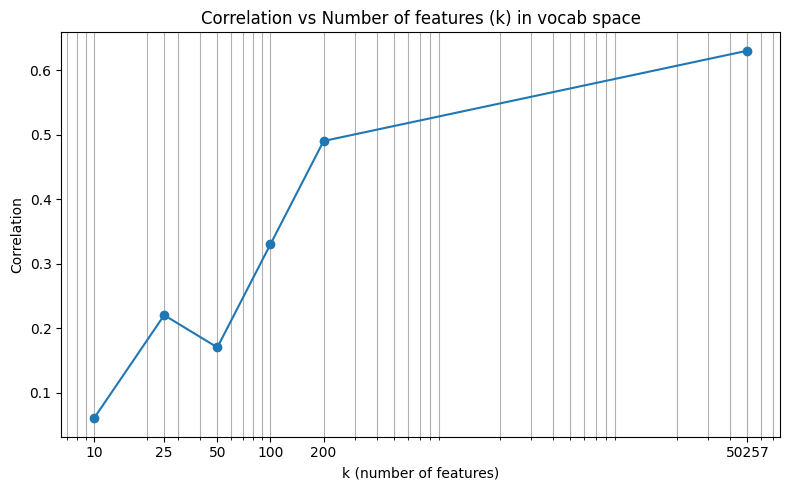

In [3]:
import matplotlib.pyplot as plt

# Data
k = [50257, 200, 100, 50, 25, 10]
corr = [0.63, 0.49, 0.33, 0.17, 0.22, 0.06]

plt.figure(figsize=(8, 5))
plt.plot(k, corr, marker='o')

plt.xscale('log')                         # log scale for spacing
plt.xticks(k, labels=[str(v) for v in k]) # ONLY show these k values

plt.xlabel("k (number of features)")
plt.ylabel("Correlation")
plt.title("Correlation vs Number of features (k) in vocab space")
plt.grid(True, which="both", axis="x")

plt.tight_layout()
plt.show()